# QF 627 Programming and Computational Finance
## Problem Set 2 | `Questions`

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# pd.set_option('display.max_columns', None)

### <font color = "blue"> `IMPORT` your dataset: `bank_loan.csv`. </font>

In [2]:
df =\
(
    pd.read_csv('bank_loan.csv')
) 

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_77250/1221477410.py:3: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv('bank_loan.csv')


### Question 1. Data `Inspection`

#### Question 1.1. How would you look at the first few rows of the DF?

In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


#### Question 1.2. How would you look at all the column names?

In [4]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

### Question 2. Data `Wrangling`

#### Question 2.1. How would you check the number of missing values in each column?

In [5]:
# df.isnull().sum()
df.isnull().sum().values

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,  2459,  1075,     0,     0,     0,     0,     0,     0,
           0, 12942,     0,    11,     0,     0,     0,     0,     0,
           0, 25682, 36931,     0,     0,     0,    50,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
          71,     0, 38577,     2,    56, 39717,     0,     0, 39717,
       39717, 39717,     0, 39717, 39717, 39717, 39717, 39717, 39717,
       39717, 39717, 39717, 39717, 39717, 39717, 39717, 39717, 39717,
       39717, 39717, 39717, 39717, 39717, 39717,    56,     0, 39717,
       39717, 39717, 39717, 39717, 39717, 39717, 39717, 39717, 39717,
       39717, 39717, 39717, 39717, 39717, 39717, 39717, 39717, 39717,
       39717, 39717, 39717, 39717, 39717, 39717,   697,    39, 39717,
       39717, 39717, 39717])

> There are columns have a large number of missing values 

> Let's clean them first.

#### Question 2.2. How would you find the percentage of missing values in each column? 
> Hint: Use the missing values and divide it by something.

In [6]:
df.isnull().sum() / df.shape[0]

id                            0.000000
member_id                     0.000000
loan_amnt                     0.000000
funded_amnt                   0.000000
funded_amnt_inv               0.000000
                                ...   
tax_liens                     0.000982
tot_hi_cred_lim               1.000000
total_bal_ex_mort             1.000000
total_bc_limit                1.000000
total_il_high_credit_limit    1.000000
Length: 111, dtype: float64

#### Question 2.3. How would you remove the columns having more than 90% missing values?

In [7]:
missing_90pct_cols =\
(
    df.columns[(df.isnull().sum() / df.shape[0]) > 0.9]
)
df =\
(
    df.drop(columns=missing_90pct_cols)
)

> Let's check the number of missing values again.

In [8]:
df.isnull().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_title                      2459
emp_length                     1075
home_ownership                    0
annual_inc                        0
verification_status               0
issue_d                           0
loan_status                       0
pymnt_plan                        0
url                               0
desc                          12942
purpose                           0
title                            11
zip_code                          0
addr_state                        0
dti                               0
delinq_2yrs                       0
earliest_cr_line                  0
inq_last_6mths              

#### Question 2.4. How would you remove columns having more than 30% of missing values?
> Hint: With so **few** columns with more than 30% missing values, can you `drop` them by **name**?

In [9]:
df.columns[(df.isnull().sum() / df.shape[0]) > 0.3]

Index(['desc', 'mths_since_last_delinq'], dtype='object')

In [10]:
df =\
(
    df.drop(columns=['desc', 'mths_since_last_delinq'])
)

> Let's check number of missing values again, does all columns have **less than** 90% missing values?

In [11]:
df.isnull().sum() / df.shape[0]

id                            0.000000
member_id                     0.000000
loan_amnt                     0.000000
funded_amnt                   0.000000
funded_amnt_inv               0.000000
term                          0.000000
int_rate                      0.000000
installment                   0.000000
grade                         0.000000
sub_grade                     0.000000
emp_title                     0.061913
emp_length                    0.027066
home_ownership                0.000000
annual_inc                    0.000000
verification_status           0.000000
issue_d                       0.000000
loan_status                   0.000000
pymnt_plan                    0.000000
url                           0.000000
purpose                       0.000000
title                         0.000277
zip_code                      0.000000
addr_state                    0.000000
dti                           0.000000
delinq_2yrs                   0.000000
earliest_cr_line         

#### Question 2.5. How would you check missing values rows-wise, by the way?
> Hint: What does the `axis` argument do?

In [12]:
df.isnull().sum(axis=1)

0        1
1        0
2        1
3        0
4        0
        ..
39712    4
39713    4
39714    5
39715    5
39716    4
Length: 39717, dtype: int64

> How would you check whether some rows have more than 5 missing values

In [13]:
df[df.isnull().sum(axis=1) > 5]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens


> The dataset is cleaned now; let's check whether all the columns are in the correct format or not.

> The column `int_rate` is character type, let's convert it to float.

In [14]:
col_int_rate =\
(
    pd.to_numeric(df['int_rate']
                  .str.replace('%',''), 
                  errors="coerce"
                  )
)
col_int_rate

0        10.65
1        15.27
2        15.96
3        13.49
4        12.69
         ...  
39712     8.07
39713    10.28
39714     8.07
39715     7.43
39716    13.75
Name: int_rate, Length: 39717, dtype: float64

#### Question 2.6. How would you use `lambda` to convert the data type of `int_rate`?

In [15]:
df.int_rate

0        10.65%
1        15.27%
2        15.96%
3        13.49%
4        12.69%
          ...  
39712     8.07%
39713    10.28%
39714     8.07%
39715     7.43%
39716    13.75%
Name: int_rate, Length: 39717, dtype: object

In [16]:
# col_int_rate =\
(
    pd.to_numeric(df.int_rate
                  .apply(
                      lambda x: x[:-1]
                  ), 
                  errors="coerce"
                  )
)

0        10.65
1        15.27
2        15.96
3        13.49
4        12.69
         ...  
39712     8.07
39713    10.28
39714     8.07
39715     7.43
39716    13.75
Name: int_rate, Length: 39717, dtype: float64

> Let's check the data types again.

In [17]:
df['int_rate'] = col_int_rate
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

> Lets extract the numeric part from the variable employment length.

> First, let's drop the missing values from the column (otherwise the regex code below throws error) using regular expression to extract numeric values from the string convert to numeric

In [18]:
df.emp_length

0        10+ years
1         < 1 year
2        10+ years
3        10+ years
4           1 year
           ...    
39712      4 years
39713      3 years
39714     < 1 year
39715     < 1 year
39716     < 1 year
Name: emp_length, Length: 39717, dtype: object

In [19]:
# col_emp_length =\
# (
#     df.emp_length.dropna()
# )

col_emp_length =\
(
    pd.to_numeric(
        df.emp_length.str.extract(r'(\d+).? year\w?')[0]
        # , errors="coerce"
    )
)

> Let's take a look at type of the columns again

In [20]:
df['emp_length'] = col_emp_length
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  float64
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

### Question 3. Exploratory Data Analysis (EDA)

> There are some variables not available at the time of loan application, and thus they cannot be used as predictors for credit approval. 

In [21]:
variables_to_remove = [
    "delinq_2yrs",
    "earliest_cr_line",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "last_credit_pull_d",
    "application_type"
]

variables_to_remove

['delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'application_type']

#### Question 3.1. How would you remove the set of variables from `variables_to_remove` from the dataset?

In [22]:
df =\
(
    df.drop(columns=variables_to_remove)
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  float64
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

#### Question 3.2. Are there any other variables that we can remove from the dataset also?

-  Also, we won't use the variables zip code, address, state etc. 
-  The variable `title` is derived from the variable `purpose` thus let get rid of all these variables as well

In [23]:
df.describe()
# based on the result,the following variables can be removed: 
# tax_liens - all values are 0
# delinq_amnt - all values are 0
# chargeoff_within_12_mths - all values are 0
# acc_now_delinq - all values are 0
# policy_code - all values are 1
# collections_12_mths_ex_med - all values are 0

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,emp_length,annual_inc,dti,collections_12_mths_ex_med,policy_code,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
count,3.971700e+04,3.971700e+04,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,38642.000000,3.971700e+04,39717.000000,39661.0,39717.0,39717.0,39661.0,39717.0,39020.000000,39678.0
mean,6.831319e+05,8.504636e+05,11219.443815,10947.713196,10397.448868,12.021177,324.561922,5.092050,6.896893e+04,13.315130,0.0,1.0,0.0,0.0,0.0,0.043260,0.0
std,2.106941e+05,2.656783e+05,7456.670694,7187.238670,7128.450439,3.724825,208.874874,3.408338,6.379377e+04,6.678594,0.0,0.0,0.0,0.0,0.0,0.204324,0.0
min,5.473400e+04,7.069900e+04,500.000000,500.000000,0.000000,5.420000,15.690000,1.000000,4.000000e+03,0.000000,0.0,1.0,0.0,0.0,0.0,0.000000,0.0
25%,5.162210e+05,6.667800e+05,5500.000000,5400.000000,5000.000000,9.250000,167.020000,2.000000,4.040400e+04,8.170000,0.0,1.0,0.0,0.0,0.0,0.000000,0.0
50%,6.656650e+05,8.508120e+05,10000.000000,9600.000000,8975.000000,11.860000,280.220000,4.000000,5.900000e+04,13.400000,0.0,1.0,0.0,0.0,0.0,0.000000,0.0
75%,8.377550e+05,1.047339e+06,15000.000000,15000.000000,14400.000000,14.590000,430.780000,9.000000,8.230000e+04,18.600000,0.0,1.0,0.0,0.0,0.0,0.000000,0.0
max,1.077501e+06,1.314167e+06,35000.000000,35000.000000,35000.000000,24.590000,1305.190000,10.000000,6.000000e+06,29.990000,0.0,1.0,0.0,0.0,0.0,2.000000,0.0


In [24]:
for col in df.columns:
    if col not in df.describe().columns:
        print(df[col].value_counts())

# based on the result,the following variables can be removed: 
# pymnt_plan - all values are "n"
# url - irrelavant
# desc - messy texts. can be replaced with column purpose 
# title - messy texts. can be replaced with column purpose 
# initial_list_status - all values are "f"

term
36 months    29096
60 months    10621
Name: count, dtype: int64
grade
B    12020
A    10085
C     8098
D     5307
E     2842
F     1049
G      316
Name: count, dtype: int64
sub_grade
B3    2917
A4    2886
A5    2742
B5    2704
B4    2512
C1    2136
B2    2057
C2    2011
B1    1830
A3    1810
C3    1529
A2    1508
D2    1348
C4    1236
C5    1186
D3    1173
A1    1139
D4     981
D1     931
D5     874
E1     763
E2     656
E3     553
E4     454
E5     416
F1     329
F2     249
F3     185
F4     168
F5     118
G1     104
G2      78
G4      56
G3      48
G5      30
Name: count, dtype: int64
emp_title
US Army                              134
Bank of America                      109
IBM                                   66
AT&T                                  59
Kaiser Permanente                     56
                                    ... 
Community College of Philadelphia      1
AMEC                                   1
lee county sheriff                     1
Bacon County Board of 

In [25]:
variables_to_remove_2 = [
    'id',
    'member_id',
    'zip_code', 
    'addr_state', 
    'tax_liens',
    'delinq_amnt',
    'chargeoff_within_12_mths',
    'acc_now_delinq',
    'policy_code',
    'collections_12_mths_ex_med',
    'pymnt_plan',
    'url',
    'desc',
    'title',
    'initial_list_status',
]
df =\
(
    df.drop(columns=variables_to_remove_2)
)

KeyError: "['desc'] not found in axis"

#### Question 3.3. Let's have a look at the target variable--`loan_status`. 

> Objecive: Re-label the values to a `binary form`: namely, `0` or `1`, 
>
> - 1 indicating that the person has defaulted and 
> - 0 otherwise.

But first, what makes up the target variable--`loan_status`?

In [ ]:
df.loan_status.value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

> You should be able to see that `fully paid` comprises most of the loans. 

> The ones marked `current` are neither fully paid not defaulted, so let's get rid of the current loans. 

> Hence, we will have two categories to label as 0 or 1.

- Filter for `Fully Paid` and `Charged Off` 
- Using `lambda`, let's label `Fully Paid` and `Charged Off`

In [ ]:
df_two_status =\
(
    df[df.loan_status
        .isin(["Charged Off", "Fully Paid"])
        ].copy()
)
col_loan_status =\
(
    df_two_status.loan_status.map({"Charged Off": 1, "Fully Paid": 0})
)

> Let's convert `loan_status` to **integer data type** (again, use `lambda`).

In [ ]:
df_two_status.loan_status =\
(
    pd.to_numeric(col_loan_status, 
                  downcast='integer')
)

> Let's take a look at the data points under the `loan_status` category.

In [ ]:
df_two_status.loan_status.value_counts()

loan_status
0    32950
1     5627
Name: count, dtype: int64

In [ ]:
df_Q4 = df_two_status

### Question 4. A Simple Univariate Analysis

> First, let's look at the overall default rate.

#### Question 4.1. How would you calculate default rate? Please use `numpy` module.

In [ ]:
# df_Q4.loan_status.sum() / df_Q4.shape[0]
df_Q4.loan_status.mean()

0.14586411592399617

> The overall default rate is about `14.6%`.  

> Let's visualize default rates across grade of the loan.

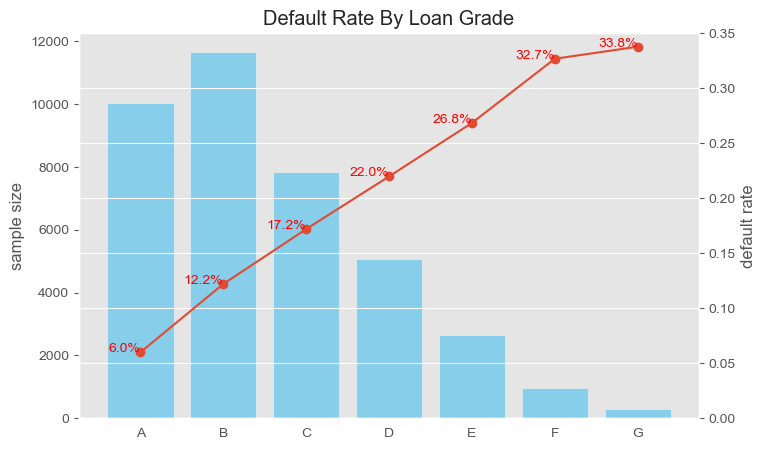

In [ ]:
plt.style.use('ggplot')

default_rate_by_grade =\
(
    df_Q4
    .groupby("grade")
    .agg(
        default_rate=("loan_status", "mean")
        , sample_size=("loan_status", "count")
    )
)

fig, ax = plt.subplots(
    figsize=(8,5)
)
ax.bar(
    default_rate_by_grade.index
    , default_rate_by_grade["sample_size"]
    , label = "sample size"
    , color = "skyblue"
)
ax.set_ylabel("sample size")
ax.grid(False)
ax2 = ax.twinx()
ax2.plot(
    default_rate_by_grade.index
    , default_rate_by_grade["default_rate"]
    , label = "default rate"
    , marker = 'o'
)
ax2.set_ylabel("default rate")
ax2.set_ylim(0, 0.35) # for easier comparison across different categorical variables
for x, y in zip(default_rate_by_grade.index, default_rate_by_grade["default_rate"]):
    ax2.annotate(
        f"{y:.1%}", (x, y)
        , ha="right"
        , color="red"
    )
plt.title("Default Rate By Loan Grade")
plt.show()

#### Question 4.2. Create a function to plot `loan_status` across `any categorical variable`.
> Hint: How did you visualise in Question 4.1? Is there a way to generalise what you did for `any categorical variable`?

In [ ]:
def plot_default_rate_by(input_df
                         , cat_col
                         , label_col = "loan_status"
                         , sort_by = None
                         ):
    # check inputs
    required_cols = [cat_col, label_col]
    missing_cols = list(set(input_df.columns) - set(required_cols))
    assert set(required_cols).issubset(input_df.columns), f"Column(s) {missing_cols} not found."
    
    # calc default rate
    res =\
    (
        input_df
        .groupby(cat_col, observed=False)
        .agg(
            default_rate=("loan_status", "mean")
            , sample_size=("loan_status", "count")
        )
    )
    if sort_by == cat_col:
        res = res.sort_index()
    elif sort_by in ["sample_size", "default_rate"]:
        res = res.sort_values(by=sort_by)
    # plot
    fig, ax = plt.subplots(
        figsize=(8,5)
    )
    ax.bar(
        res.index
        , res["sample_size"]
        , label = "sample size"
        , color = "skyblue"
    )
    ax.set_ylabel("sample size")
    ax.grid(False)
    ax2 = ax.twinx()
    ax2.plot(
        res.index
        , res["default_rate"]
        , label = "default rate"
        , marker = 'o'
    )
    ax2.set_ylabel("default rate")
    ax2.set_ylim(0, 0.35) # for easier comparison across different categorical variables
    for x, y in zip(res.index, res["default_rate"]):
        ax2.annotate(
            f"{y:.1%}", (x, y)
            , ha="right"
            , color="red"
        )
    fig.autofmt_xdate() 
    plt.title(f"Default Rate By {cat_col}")
    plt.show()

#### How's default rates across `grade` of loan? Use your newly created function :)

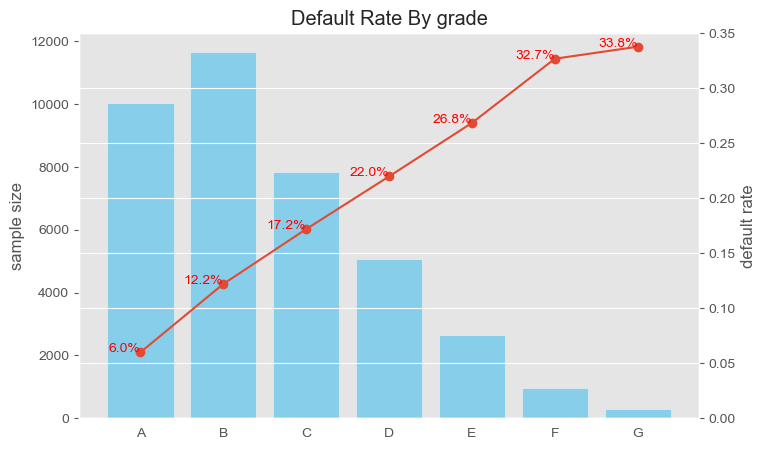

In [ ]:
plot_default_rate_by(df_Q4, "grade")

> What is your `interpretation`?

> A:

> The variable grade has good distinguishing power on default rate. As we can see from the graph, default rates rise monotonically and significantly accoss different grades, from 6% at grade A to 33.8% at grade G. Although the default rates of grade F and G might be statistically unstable due to the small sample size.

#### `term`

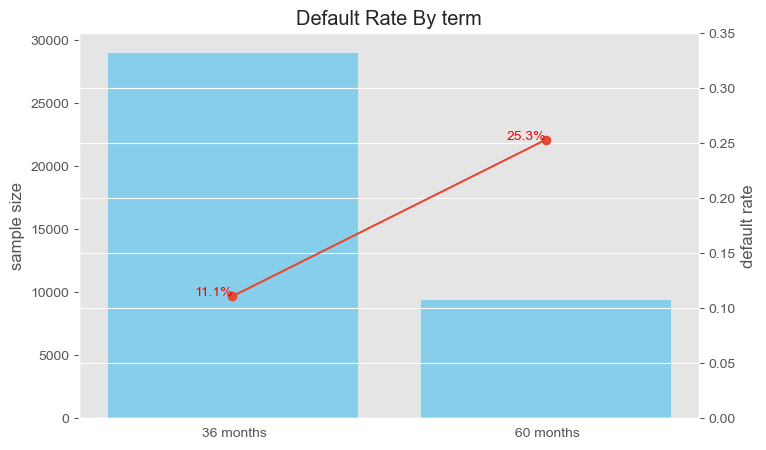

In [ ]:
plot_default_rate_by(df_Q4, "term")

> What is your `interpretation`?

> A:

> The variable term can be seen as one of the factors of default rate. Based on the above result, we know that 60-month loans have significantly higher possibility of default comparing to 36-month loans, hence should require more conservative credit policy and higher compensation.

> But we can't conclude that there is correlation between longer loan terms and higher default rates as the data is limited. If the bank offers product with a different term other than 36 and 60 months, default rate should be assessed separately.

#### `home_ownership`

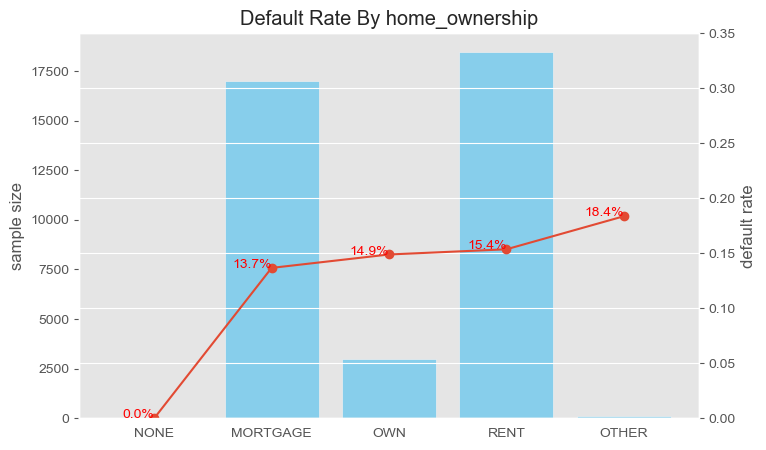

In [ ]:
plot_default_rate_by(df_Q4, "home_ownership", sort_by="default_rate")

> What is your `interpretation`?

> A:

> We can ignore the "NONE" and "OTHER" category due to small sample size. Among the remaining three categories, the default rates are very close to each other and the overall average value. So the variable home_ownership doesn't show much distinguish power here.

#### The role of `verification_status`?

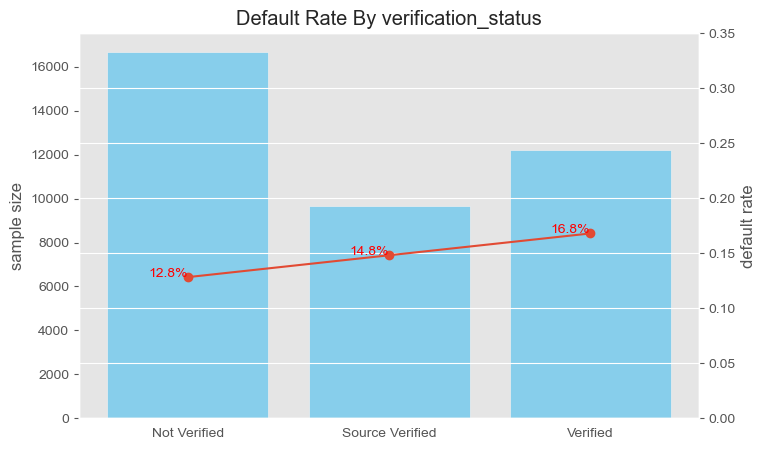

In [ ]:
plot_default_rate_by(df_Q4, "verification_status")

> What is your `interpretation`? 

> A:

> There is only 2% difference in default rate between each adjacent category. The variable verification_status might be a very weak factor. It takes further examination to tell whether the differences are statistically significant or not.

#### The role of Loan `purpose`?

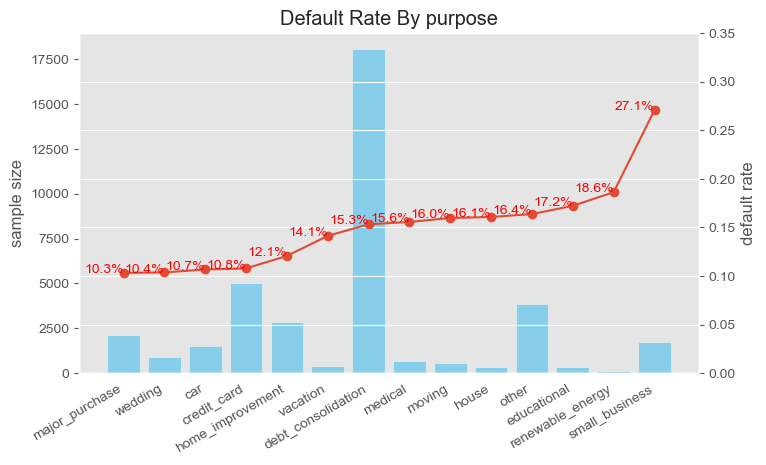

In [ ]:
plot_default_rate_by(df_Q4, "purpose", sort_by="default_rate")

> What is your `interpretation`?

> A:

> The sample sizes across categories are highly imbalanced, with very large groups like "debt_consolidation" (18055 loans) and very tiny groups like "renewable energy" (102 loans). For "small_business" and "credit_card", the large gaps in default rate comparing to the overall average probably have statistical significance, whereas others need further examination to tell. If this variable is to be used in predictive modeling, a tiered regrouping (by merging similar risk level categories like "car", "credit_card", "major_purchase" and "wedding") might improve stability and give higher distinguishing power.

#### Question 4.3. How is the distribution of loans across time?

> Please convert the column `issue_d` into datetime and then extract year and month from it.

In [ ]:
df_Q4["issue_d"] =\
(
    pd.to_datetime(df_Q4["issue_d"]
                   , format="%b-%y")
)

> Yes, please use `lambda`.

> Please extract month and year from `issue_d`, using `lambda`.

In [ ]:
df_Q4['issue_y'] =\
(
    df_Q4["issue_d"]
    .dt
    .year
)

df_Q4['issue_m'] =\
(
    df_Q4["issue_d"]
    .dt
    .month
)

> How would you examine the number of loans granted across `years`?

In [ ]:
(
    df_Q4['issue_y']
    .value_counts()
)

issue_y
2011    20516
2010    11532
2009     4716
2008     1562
2007      251
Name: count, dtype: int64

You can see that the number of loans has increased steadily across years. 

> How would you examine the number of loans across months?

In [ ]:
(
    df_Q4['issue_m']
    .value_counts()
    .sort_index()
)

issue_m
1     2379
2     2358
3     2691
4     2831
5     2919
6     3180
7     3351
8     3388
9     3498
10    3761
11    4006
12    4215
Name: count, dtype: int64

> `Interpretation`?

> A:

> The number of loans increases from Jan to Dec.  On average, the last quarter contributes more than 30% to the total number of loans throughout a year.

#### Compare the default rates across years.

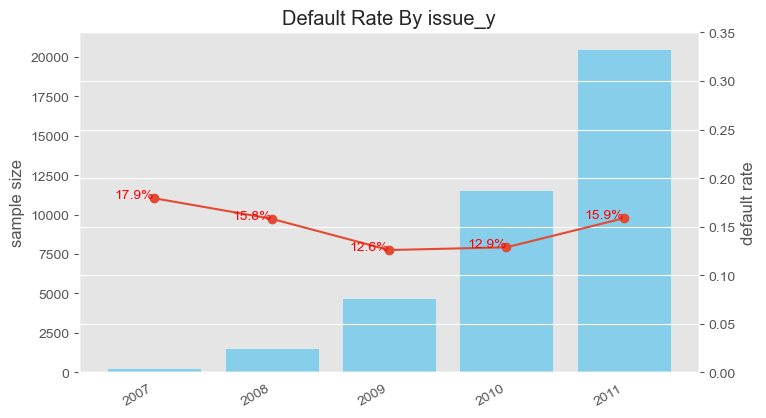

In [ ]:
plot_default_rate_by(df_Q4, "issue_y")

> `Interpretation`?

> A:

> For 2007 and 2008, there isn't much to tell due to the small sample size. Starting from 2009, default rate is not always stable, it can be fluctuated across different years, influenced by ecnomic regime, bank's risk appetite or else. So time should be taken into consideration for default rate analysis.

#### Let's compare default rates across months.

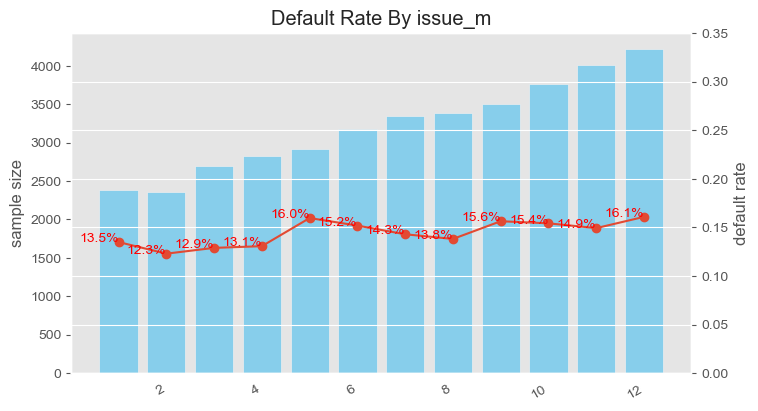

In [ ]:
plot_default_rate_by(df_two_status, "issue_m")

> `Interpretation`? 

> A:

> Seems May and Dec have higher default rate comparing to other months.

#### Question 4.4. Let's now analyse how the default rate varies across continuous variables.

> Loan Amount: `loan_amnt`

In [ ]:
# def plot_default_rate_by_bin(input_df, continuous_var, bin_num=10):
#     assert continuous_var in input_df.columns, f"Column {continuous_var} not found."
#     temp_df =\
#         input_df[[
#             "loan_status", 
#             continuous_var
#         ]].copy()
#     temp_df[f"{continuous_var}_bin"] =\
#         pd.qcut(
#             input_df[continuous_var],
#             q=bin_num
#         )
#     default_rate_groupby_bin =\
#     (
#         temp_df
#         .groupby(f"{continuous_var}_bin")
#         .loan_status
#         .sum() 
#         / (
#             temp_df
#             [f"{continuous_var}_bin"]
#             .value_counts()
#         )
#     )

#     default_rate_groupby_bin.plot(
#         kind='bar',
#         title=f'Default Rate By {continuous_var} (bin_num={bin_num})'
#     )
#     plt.ylabel("Default Rate")
#     plt.show()

In [ ]:
# default_rate_by_loan_amnt =\
(
    df_Q4
    .groupby("loan_amnt")
    .agg(
        default_rate=("loan_status", "mean")
        , sample_size=("loan_status", "count")
    ).sort_values(
        by="sample_size"
        , ascending=False
    )
)

,default_rate,sample_size
loan_amnt,,
10000,0.128871,2809
12000,0.134786,2248
5000,0.141519,2028
6000,0.112937,1886
15000,0.140914,1838
...,...,...
19450,0.000000,1
19475,1.000000,1
19550,0.000000,1


> `Interpretation`?

> A:

> For continuous variable like "loan_ammt", if we also using the same way as we treat categorical variables, results will have too many categories with most of them having tiny sample size. One way to solve this is to bin the variables first.

> Another way to analyse how default rates vary across continous variables is to bin the variables into discrete categories.

> Let's create a categorical variable for the loan amount variable into small, medium, high, very high.

* loan_amount < 5000 `low`
* loan_amount >=5000 and loan_amount < 15000 `medium`
* loan_amount >= 15000 and loan_amount < 25000 `high`
* greater than 25000 `very high`

In [ ]:
df_Q4["loan_amnt_bin"] =\
(
    pd.cut(
        df_Q4["loan_amnt"]
        , bins=[0, 5000, 15000, 25000, np.inf]
        , labels=["low", "medium", "high", "very high"]
        , right=False
    )
)
df_Q4\
    .groupby("loan_amnt_bin", observed=False)\
    ["loan_amnt"]\
    .agg(['min','max','count'])

,min,max,count
loan_amnt_bin,,,
low,500,4975,7444
medium,5000,14975,20675
high,15000,24975,7696
very high,25000,35000,2762


In [ ]:
# alternative way to create bins
bins = [5000, 15000, 25000]
labels = np.array(["low", "medium", "high", "very high"])
alternative_loan_amnt_bin =\
(
    df_Q4["loan_amnt"]
        .apply(
            lambda x: labels[
                np.searchsorted(
                    bins
                    ,x
                    ,side="right"
                )
            ]
        )
)
alternative_loan_amnt_bin.value_counts()

loan_amnt
medium       20675
high          7696
low           7444
very high     2762
Name: count, dtype: int64

> Let's compare the default rates across loan amount type

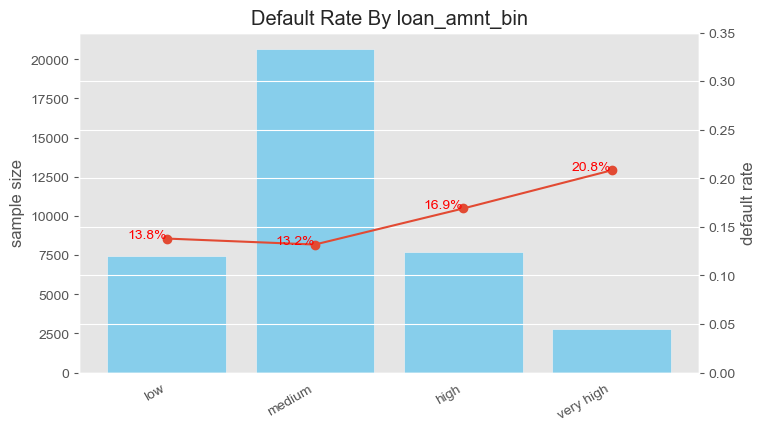

In [ ]:
plot_default_rate_by(df_Q4, "loan_amnt_bin")

> `Interpretation`?

> A:

> The variable loan_amnt has some distinguishing power on default rate. For loans falling into "high" (>=15k) category, default rate increases by ~2.3% whereas for those in "very high" (>=25k) category, default rate increases by ~6.2%, comparing to the overall average.

#### Let's also convert funded amount invested to bins (using the same scheme from `loan_amount`)

In [ ]:
df_Q4["funded_amnt_bin"] =\
(
    pd.cut(
        df_Q4["funded_amnt"],
        bins=[0, 5000, 15000, 25000, np.inf],
        labels=["low", "medium", "high", "very high"],
        right=False
    )
)
df_Q4\
    .groupby("funded_amnt_bin", observed=False)\
    ["funded_amnt"]\
    .agg(['min','max','count'])

,min,max,count
funded_amnt_bin,,,
low,500,4975,7538
medium,5000,14975,21152
high,15000,24975,7539
very high,25000,35000,2348


> Visualize the results

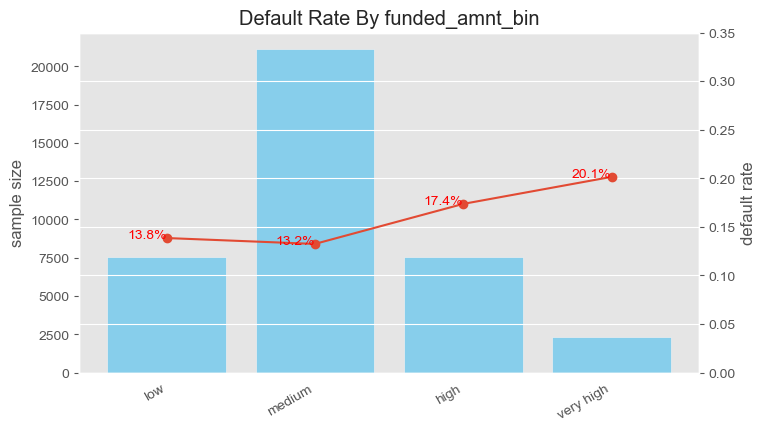

In [ ]:
plot_default_rate_by(df_Q4, "funded_amnt_bin")

#### Interest Rate (int_rate)

> Use the following definitions for each categories.

* <= 10 `low`
* dti > 10 and dti <=15 `medium`
* greater than 15 `high`

> Use lambda for creating a new categorical variable.

In [ ]:
df_Q4["int_rate_bin"] =\
(
    pd.cut(
        df_Q4["int_rate"],
        bins=[0, 10, 15, np.inf],
        labels=["low", "medium", "high"],
        right=True
    )
)
df_Q4\
    .groupby("int_rate_bin", observed=False)\
    ["int_rate"]\
    .agg(['min','max','count'])

,min,max,count
int_rate_bin,,,
low,5.42,10.00,12316
medium,10.01,14.96,18265
high,15.01,24.40,7996


> Let's compare default rates across rates of interest

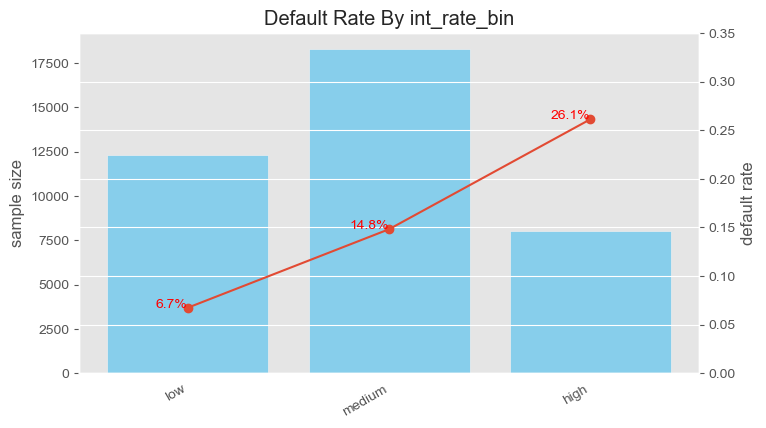

In [ ]:
plot_default_rate_by(df_Q4, "int_rate_bin")

> `Interpretaion`?

> A:

> The variable int_rate has good distinguish power on default rate. As we can see from the graph, default rates rise monotonically and significantly accoss different int_rate bins, from 6.7% at low int_rate (<=10%) to 26.1% at high int_rate (>15%).

#### debt-to-income (`dti`) ratio

> Please create a categorical variable of `dti` using your own function

> Use the following definitions for each categories.

* <= 10 `low`
* dti > 10 and dti <=20 `medium`
* greater than 20 `high`

> Use lambda for creating a new variable.

In [ ]:
df_Q4["dti_bin"] =\
(
    pd.cut(
        df_Q4["dti"],
        bins=[0, 10, 20, np.inf],
        labels=["low", "medium", "high"],
        right=True
    )
)
df_Q4\
    .groupby("dti_bin", observed=False)\
    ["dti"]\
    .agg(['min','max','count'])

,min,max,count
dti_bin,,,
low,0.01,10.00,12757
medium,10.01,20.00,18441
high,20.01,29.99,7201


> Let's comparing default rates across debt to income ratio

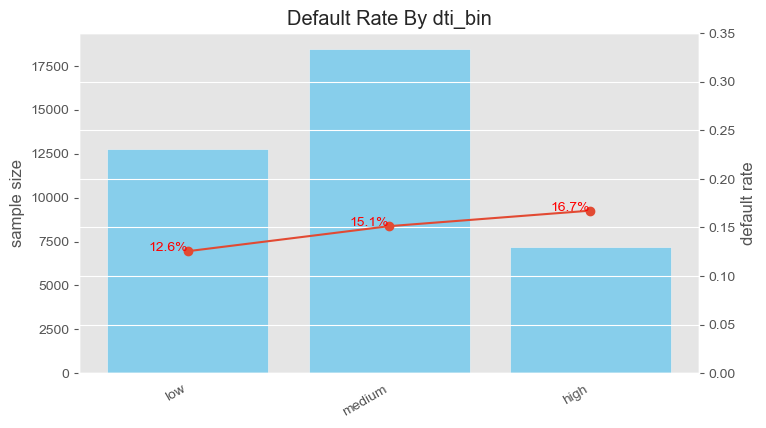

In [ ]:
plot_default_rate_by(df_Q4, "dti_bin")

> `Interpretation`?

> A:

> The variable dti has some distinguish power on default rate but not as much as int_rate. The gap between the highest default rate (16.7%) and the lowest default rate (12.6%) among the categories is only 4.1%, comparing to ~20% for int_rate.

#### `funded_amount`

> Please create a categorical variable of `funded_amount` using your own function

> Use the following definitions for each categories.

- <= 5000 `low`
- funded_amount > 5000 and funded_amount <=15000 `medium`
- greater than 15000 `high`

> Use lambda for creating a new variable.

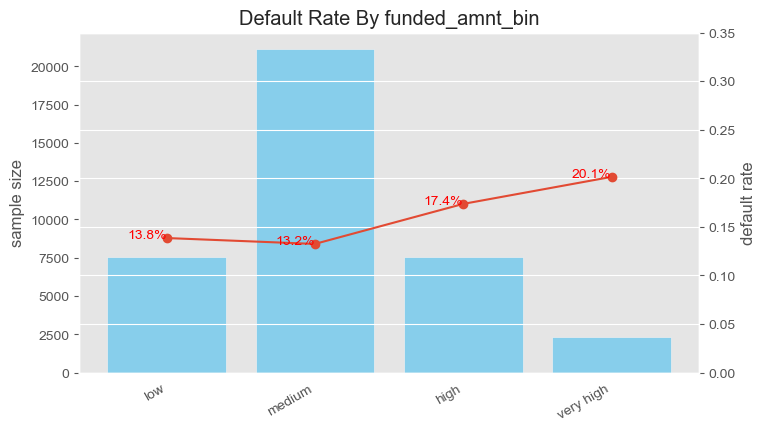

In [ ]:
plot_default_rate_by(df_Q4, "funded_amnt_bin")

#### `installment`

> Please create a categorical variable of `installment` using your own function

> Use the following definitions for each categories.

- installment <= 200 `low`
- installment > 200 and installment <= 400 `medium`
- installment > 400 and installment <= 600 `high`
- greater than 600 = `very high`

> Use lambda for creating a new variable.

In [ ]:
df_Q4["installment_bin"] =\
(
    pd.cut(
        df_Q4["installment"],
        bins=[0, 200, 400, 600, np.inf],
        labels=["low", "medium", "high", "very high"],
        right=True
    )
)
df_Q4\
    .groupby("installment_bin", observed=False)\
    ["installment"]\
    .agg(['min','max','count'])

,min,max,count
installment_bin,,,
low,15.69,199.95,13074
medium,200.01,399.97,14732
high,400.04,599.99,6563
very high,600.03,1305.19,4208


> Let's compare default rates across installment

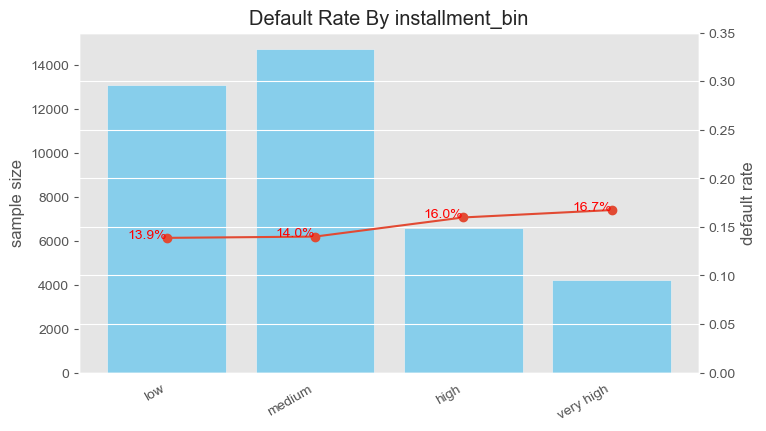

In [ ]:
plot_default_rate_by(df_Q4, "installment_bin")

> `Interpretation`?

> A:

> There is not much distinguishing power in variable installment. The default rates in each category is quite close to each other.

#### How about `annual_income`? 

> Please create a categorical variable of annual_income using your own function

> Use the following definitions for each categories.

- less than or equal to 50k = `low`
- greater than 50k less than equal to 100 k = `medium`
- greater than 100k less than equal to 150k = `high`
- greater than 150k = `very high`

> Use lambda for creating a new variable.

In [ ]:
df_Q4["annual_inc_bin"] =\
(
    pd.cut(
        df_Q4["annual_inc"],
        bins=[0, 50000, 100000, 150000, np.inf],
        labels=["low", "medium", "high", "very high"],
        right=True
    )
)
df_Q4\
    .groupby("annual_inc_bin", observed=False)\
    ["annual_inc"]\
    .agg(['min','max','count'])

,min,max,count
annual_inc_bin,,,
low,4000.00,50000.0,15389
medium,50000.04,100000.0,17707
high,100008.00,150000.0,3995
very high,150060.00,6000000.0,1486


> Visualize the results.

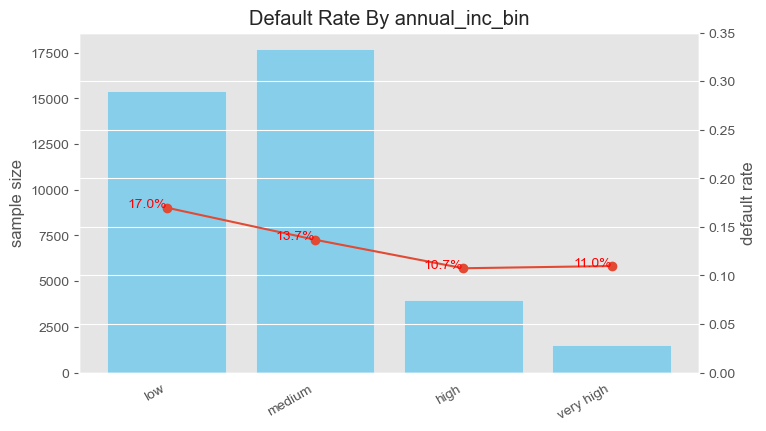

In [ ]:
plot_default_rate_by(df_Q4, "annual_inc_bin")

> What's your interpretation?

> A:

> The variable annual_inc has some distinguishing power on default rate, with default rates in "low" and "high" category clearly deviate from the overall average. 

#### `Employment Length`

> First, let's drop the missing value observations in `emp_length`

> Please create a categorical variable of `emp_length` using your own function

> Use the following definitions for each categories.

* emp_length <= 1 `fresher`
* emp_length > 1 and emp_length <=3 `junior`
* emp_length > 3 and emp_length <=7 `senior`
* greater than 7 `expert`

> Use lambda for creating a new variable.

In [ ]:
df_Q4["emp_length_bin"] =\
(
    pd.cut(
        df_Q4["emp_length"],
        bins=[0, 1, 3, 7, np.inf],
        labels=["fresher", "junior", "senior", "expert"],
        right=True
    )
)
df_Q4["emp_length_bin"] =\
(
    df_Q4["emp_length_bin"]
    .cat.add_categories("unknown")
    .fillna("unknown")
)
df_Q4\
    .groupby("emp_length_bin", observed=False)\
    ["emp_length"]\
    .agg(['min','max','size'])

,min,max,size
emp_length_bin,,,
fresher,1.0,1.0,7677
junior,2.0,3.0,8303
senior,4.0,7.0,10415
expert,8.0,10.0,11149
unknown,NaN,NaN,1033


> Visualize the results

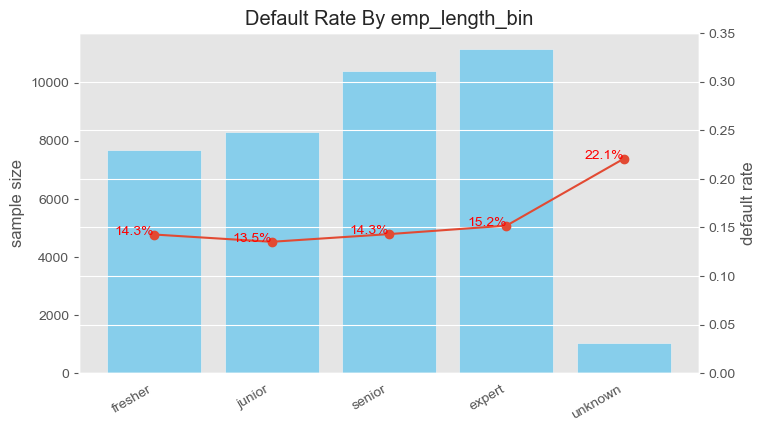

In [ ]:
plot_default_rate_by(df_Q4, "emp_length_bin")

> What's your `interetation`?

> A:

> The default rate in each category of variable emp_length is quite close to each other, except for the "unknown" category, with 22.1% default rate. But it might not reliable due to the small sample size. Other than that, emp_length doesn't have much distinguishing power.

### Question 5. Segmented Univariate Analysis



#### Question 5.1. A quick glance on Loan Purpose (`purpose`) using your first function :)

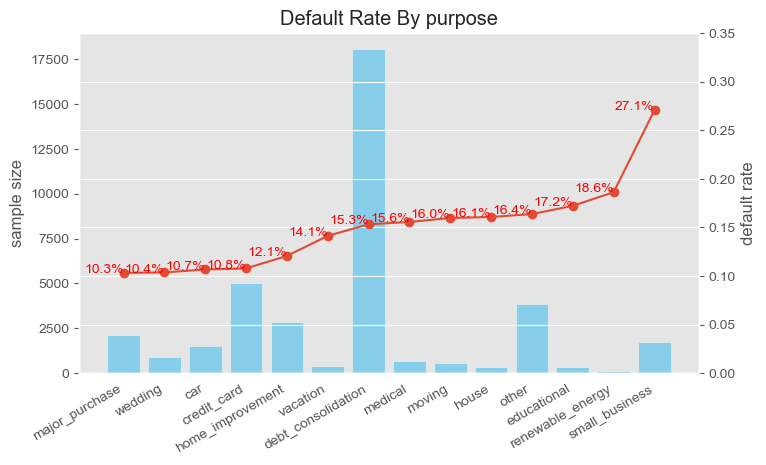

In [ ]:
plot_default_rate_by(df_Q4, "purpose", sort_by="default_rate")

> `Interpretation`?

> A:

> The sample sizes across categories are highly imbalanced, with very large groups like "debt_consolidation" (18055 loans) and very tiny groups like "renewable energy" (102 loans). For "small_business" and "credit_card", the large gaps in default rate comparing to the overall average probably have statistical significance, whereas others need further examination to tell. If this variable is to be used in predictive modeling, a tiered regrouping (by merging similar risk level categories like "car", "credit_card", "major_purchase" and "wedding") might improve stability and give higher distinguishing power.

#### Question 5.2. Now let's segment the loan applications across the purpose of the loan, since that is a variable affecting many other variables - the type of applicant, interest rate, income, and finally the default rate. 

> Let's take a look at the number of loans for each type (purpose) of the loan.

In [ ]:
df_Q4["purpose"].value_counts()

purpose
debt_consolidation    18055
credit_card            5027
other                  3865
home_improvement       2875
major_purchase         2150
small_business         1754
car                    1499
wedding                 926
medical                 681
moving                  576
vacation                375
house                   367
educational             325
renewable_energy        102
Name: count, dtype: int64

> Please analyze the top 4 types of loans based on purpose

#### Let's filter the df for the 4 types of loans mentioned above

In [ ]:
df_top4_purpose =\
(
    df_Q4[df_Q4["purpose"].isin([
        "debt_consolidation",
        "credit_card",
        "other",
        "home_improvement"
    ])]
)
df_top4_purpose.shape

(29822, 28)

#### Visualize the number of loans by purpose 

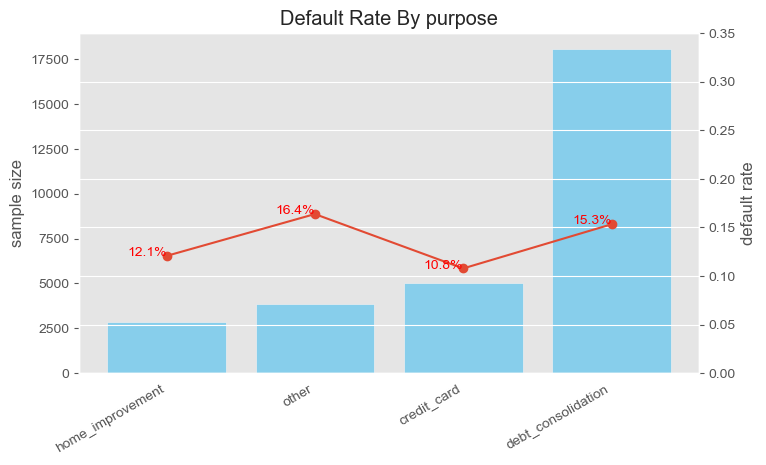

In [ ]:
plot_default_rate_by(df_top4_purpose, "purpose", sort_by="sample_size")

> let's now compare the default rates (`loan_status`) across two types of categorical variables;
> - `purpose` of loan (constant)
> - another categorical variable (which changes)

> You should be able to write your own function which takes a categorical variable and plots the default rate segmented by purpose.

> Please **create your function** named `plot_segmented`

In [ ]:
def plot_segmented(input_df
                   , seg_col
                   , cat_col
                   , label_col = "loan_status"
                   ):
    # check inputs
    required_cols = [seg_col, cat_col, label_col]
    missing_cols = list(set(input_df.columns) - set(required_cols))
    assert set(required_cols).issubset(input_df.columns), f"Column(s) {missing_cols} not found."
    
    seg_values = input_df[seg_col].unique()
    # calc default rate
    res =\
    (
        input_df
        .groupby([seg_col, cat_col], observed=True)
        .agg(
            default_rate=("loan_status", "mean")
            , sample_size=("loan_status", "size")
        )
    )
    second_index =\
    (
        res.index
        .get_level_values(1)
        .unique()
    )
    res =\
    (
        res.reindex(
            second_index, 
            level=1
        )
    )
    
    # plot
    fig, axs = plt.subplots(
        1,
        len(seg_values),
        figsize=(14,4),
        sharey=True,
        sharex=True
    )
    secondary_axes = []
    for i, p in enumerate(seg_values):
        ax = axs[i]
        ax.bar(
            res.loc[p].index
            , res.loc[p]["sample_size"]
            , label = "sample size"
            , color = "skyblue"
        )
        ax.set_ylabel("sample size")
        ax.grid(False)
        ax.set_title(
            f'Default Rate By {cat_col} \n({seg_col}={p})',
            fontsize=12
        )
        ax2 = ax.twinx()
        ax2.plot(
            res.loc[p].index
            , res.loc[p]["default_rate"]
            , label = "default rate"
            , marker = 'o'
        )
        ax2.set_ylabel("default rate")
        ax2.set_ylim(0, 0.5) # for easier comparison across different categorical variables
        for x, y in zip(res.loc[p].index, res.loc[p]["default_rate"]):
            ax2.annotate(
                f"{y:.1%}", (x, y)
                , ha="right"
                , color="red"
            )
        secondary_axes.append(ax2)
    
    ymins = [ax.get_ylim()[0] for ax in secondary_axes]
    ymaxs = [ax.get_ylim()[1] for ax in secondary_axes]
    for ax2 in secondary_axes:
        ax2.set_ylim((min(ymins), max(ymaxs)))
    
    fig.autofmt_xdate() 
    plt.show()

> Let's use the function to see if there's differences in the term.

#### Grade of Loan (`grade`)

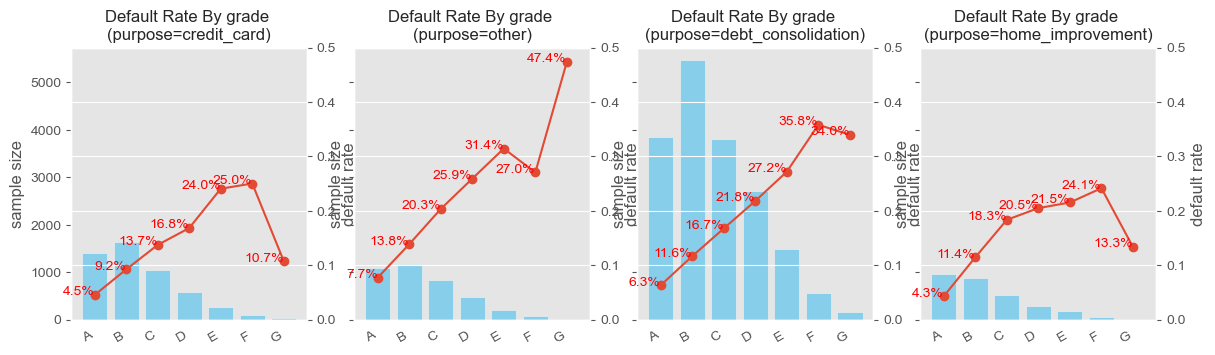

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "grade")

#### home ownership(`home_ownership`)

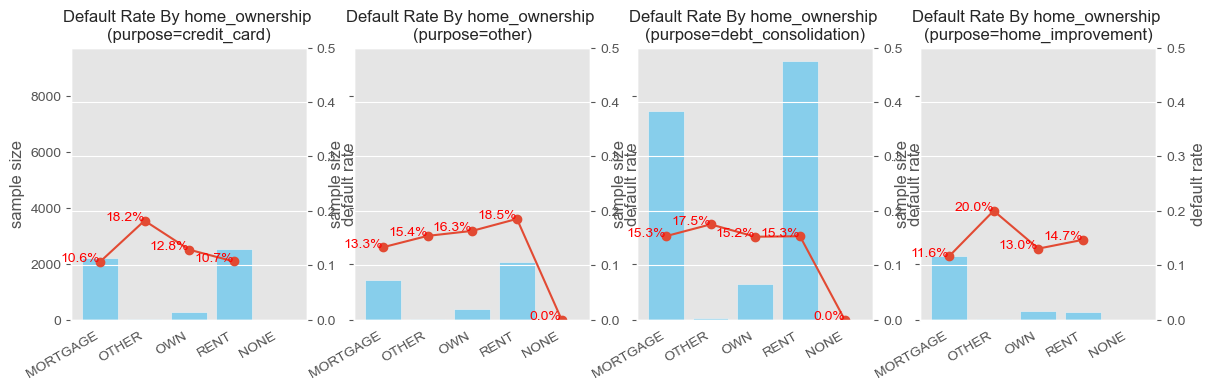

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "home_ownership")

#### `year`

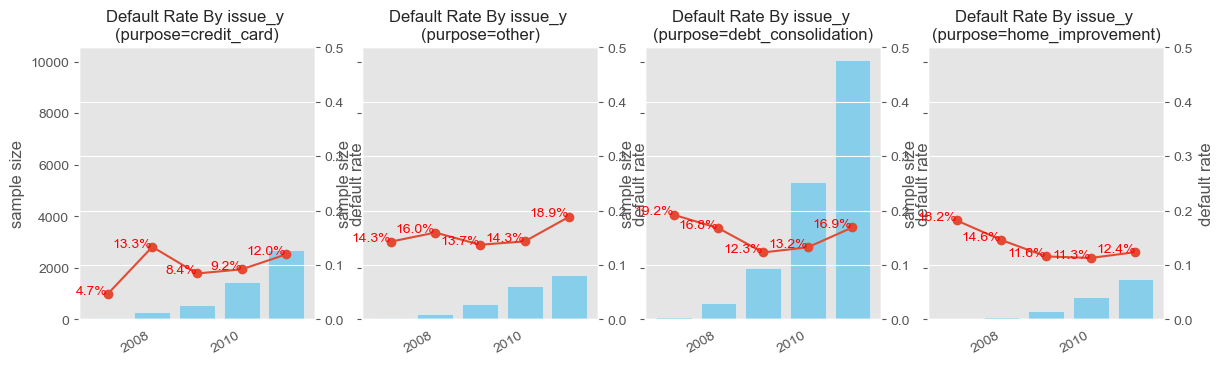

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "issue_y")

#### `emp_length`

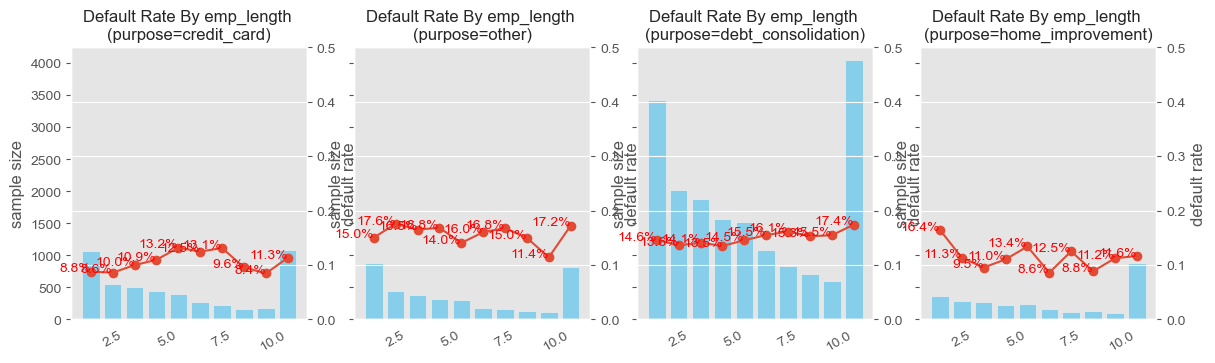

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "emp_length")

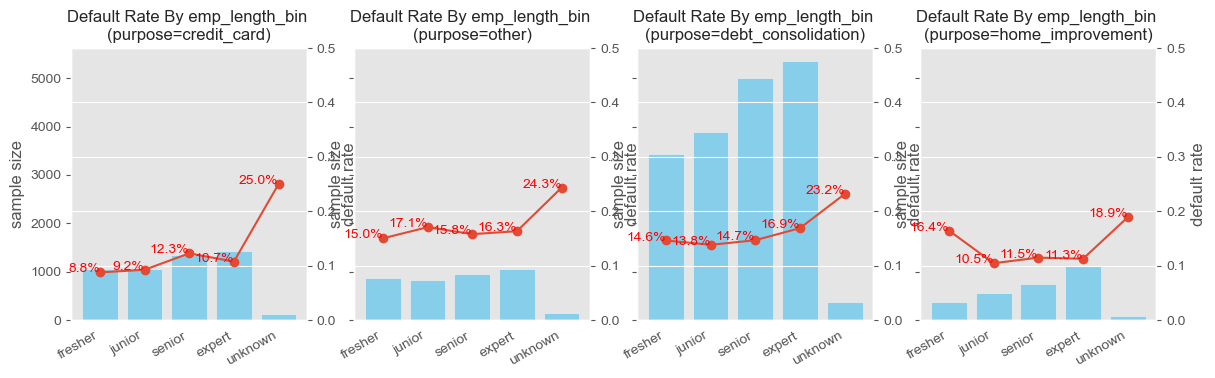

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "emp_length_bin")

> Loan Amount (`loan_amnt`) 

> How's the pattern compared with loan purposes?

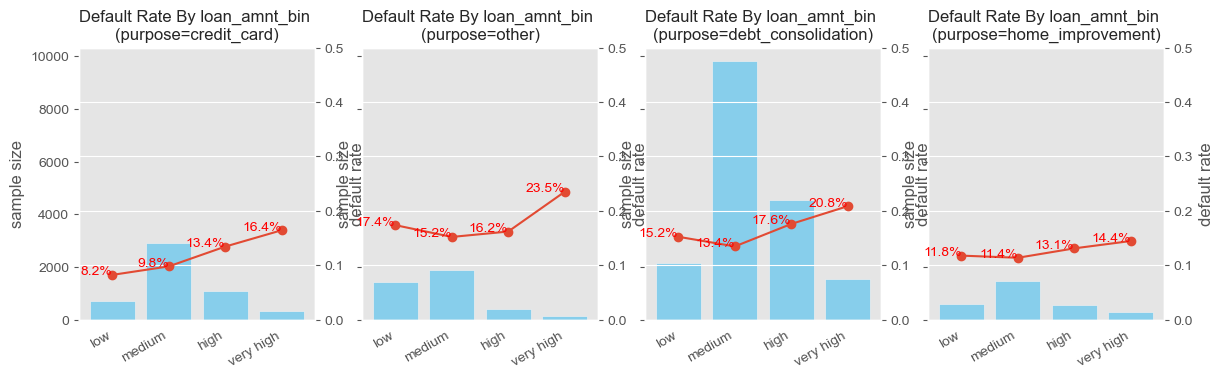

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "loan_amnt_bin")

> interest rate (`int_rate`)

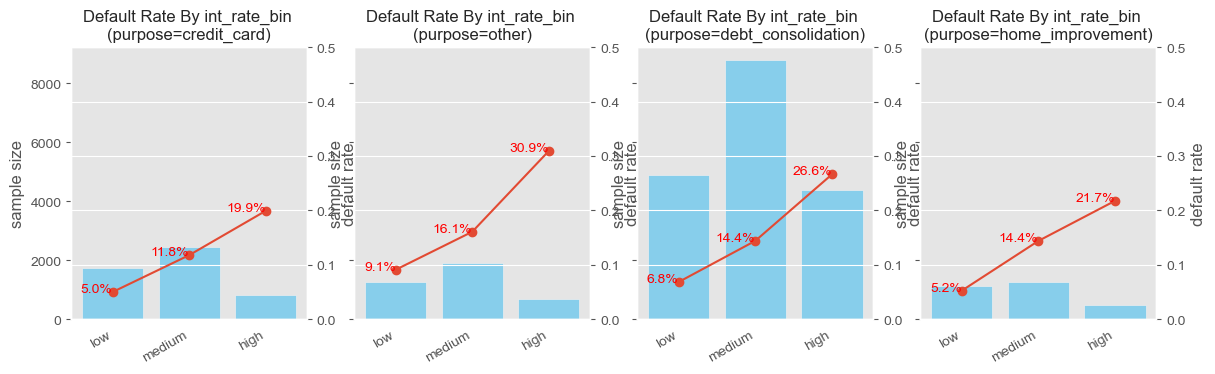

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "int_rate_bin")

> `installment`

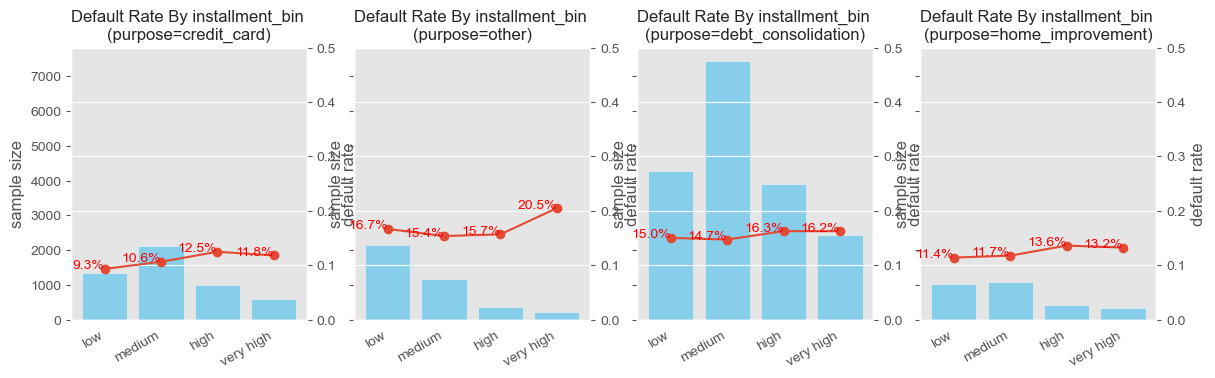

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "installment_bin")

> debt-to-income (`dti`) ratio

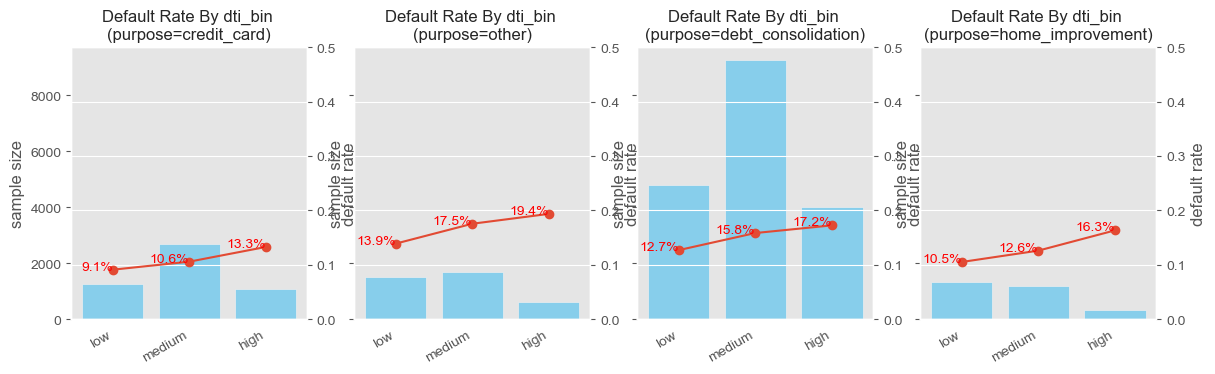

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "dti_bin")

> Let's have a look at the role of `annual_income`

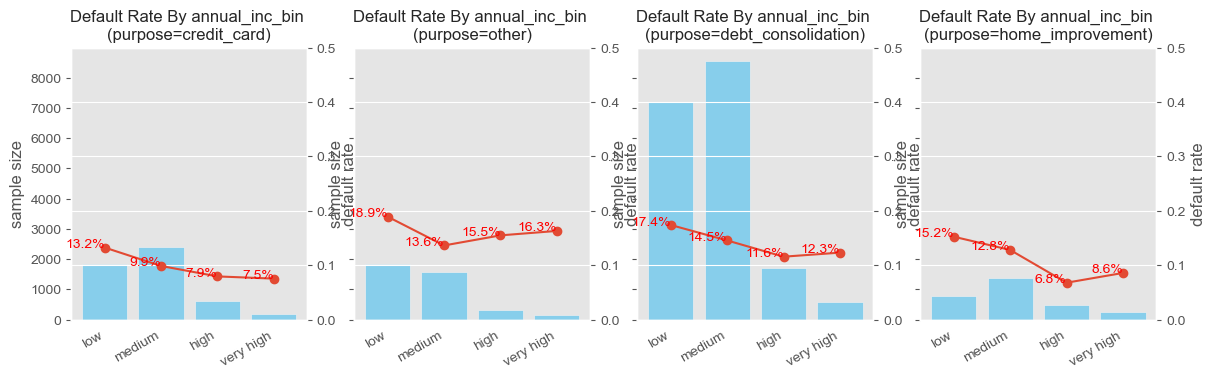

In [ ]:
plot_segmented(df_top4_purpose, "purpose", "annual_inc_bin")

> A good way to quantify the effect of a categorical variable on default rate is to see `how much does the default rate vary across the categories`. 

> Let's see an example using `annual_inc` as the categorical variable.

> How would you examine the variation of default rate across `annual_inc`?

> A:

> As shown below, the standard deviation of default rate across categories of `annual_inc` is 2.9%

In [ ]:
default_rate_by_annual_inc_bin =\
(
    df_Q4.groupby("annual_inc_bin", observed=False)
    .agg(
            default_rate=("loan_status", "mean")
            # , sample_size=("loan_status", "size")
        )
)
default_rate_by_annual_inc_bin.describe()

,default_rate
count,4.000000
mean,0.130913
std,0.029157
min,0.107384
25%,0.109114
50%,0.123236
75%,0.145036
max,0.169797


#### Question 5.3 Write a function which takes in a categorical variable and computed the average default rate across the categories.

> You can also compute the `difference between the highest and the lowest default rate` across the categories, which is a decent metric indicating the effect of the varaible on default rate.

> Please create your own function named `diff_rate`.

In [ ]:
def diff_rate(input_df 
              , cat_col
              , label_col = "loan_status"
              ):
    # check inputs
    required_cols = [cat_col, label_col]
    missing_cols = list(set(input_df.columns) - set(required_cols))
    assert set(required_cols).issubset(input_df.columns), f"Column(s) {missing_cols} not found."
    res =\
    (
        input_df.groupby(cat_col, observed=False)
        .agg(
                default_rate=(label_col, "mean")
                # , sample_size=("loan_status", "size")
            )
    )
    return (res.max().iloc[0] - res.min().iloc[0])

In [ ]:
# or we can also use IV (Information Value) to messure the effect of variables on default rate
def calc_iv(input_df 
              , cat_col
              , label_col = "loan_status"
              ):
    # check inputs
    required_cols = [cat_col, label_col]
    missing_cols = list(set(input_df.columns) - set(required_cols))
    assert set(required_cols).issubset(input_df.columns), f"Column(s) {missing_cols} not found."

    iv = 0
    bad_in_bin =\
    (
        input_df.groupby(cat_col, observed=False)
        [label_col]
        .sum()
    )
    good_in_bin =\
    (
        input_df[cat_col]
        .value_counts()
        - bad_in_bin
    )
    bad_total =\
    (
        input_df[label_col].sum()
    )
    good_total =\
    (
        input_df.shape[0]
        - bad_total
    )
    bad_disb_in_bin = bad_in_bin / bad_total
    good_disb_in_bin = good_in_bin / good_total
    woe = np.log(
        (good_disb_in_bin + 1e-8) / (bad_disb_in_bin + 1e-8)
    )
    iv =\
    (
        ((good_disb_in_bin - bad_disb_in_bin) * woe)
        .sum()
    )
    return iv, dict(woe)
    


> Please use the function and draw some insights :)

> A:

> From the result below we can see that `sub_grade` has the most distinguishing power according to both `diff_rate()` and `calc_iv()` function.

> According to the iv results, `sub_grade`, `grade`, `int_rate_bin` are strong predictors and `term` is medium predictor, whereas the rest has weak predicting power or not useful.

> The two functions give different implications on `home_ownership` - according to `diff_rate()` it has the 4th most effect on default rate whereas according to iv it's not useful. This is due to the small sample size of the "OTHER" category which gives unstable result of default_rate, hence leads to a misleading number of large rate difference among categories. This is also the limitation of using the difference between max and min default rate to assess the effect of the variables.

In [ ]:
candidate_vars = [
    'term'
    , 'int_rate_bin'
    , 'grade'
    , 'sub_grade'
    , 'home_ownership'
    , 'verification_status'
    , 'purpose'
    , 'issue_y'
    , 'issue_m'
    , 'loan_amnt_bin'
    , 'funded_amnt_bin'
    , 'dti_bin'
    , 'installment_bin'
    , 'annual_inc_bin'
    , 'emp_length_bin'
]
res_dict = {}

for var in candidate_vars:
    res_dict[var] = {
        "default_rate_diff": diff_rate(df_Q4, var),
        "iv": calc_iv(df_Q4, var)[0],
        "cat_num": len(df_Q4[var].unique()),
        "cat_size_min": df_Q4.groupby(var, observed=False).size().min()
    }

# res =\
(
    pd.DataFrame
    .from_dict(res_dict, orient="index")
    .sort_values(by="default_rate_diff", ascending=False)
)

,default_rate_diff,iv,cat_num,cat_size_min
sub_grade,0.451537,0.372294,35,29
grade,0.277862,0.339853,7,299
int_rate_bin,0.193989,0.313135,3,7996
home_ownership,0.183673,0.005353,5,3
purpose,0.167554,0.072133,14,102
term,0.142229,0.211518,2,9481
emp_length_bin,0.085584,0.010697,5,1033
loan_amnt_bin,0.076381,0.029795,4,2762
funded_amnt_bin,0.069026,0.026964,4,2348
annual_inc_bin,0.062412,0.031181,4,1486


> Thus, there is a ***`45%`*** increase in default rate as you go from high to low annual income. 

##### You might want to compute this difference for all the variables and roughly identify the ones that affect default rate the most.

### Variables in the Dataset

- `acc_now_delinq`	The number of accounts on which the borrower is now delinquent.
- `acc_open_past_24mths`	Number of trades opened in past 24 months.
- addr_state`	The state provided by the borrower in the loan application
- `all_util`	Balance to credit limit on all trades
- `annual_inc`	The self-reported annual income provided by the borrower during registration.
- `annual_inc_joint`	The combined self-reported annual income provided by the co-borrowers during registration
- `application_type`	Indicates whether the loan is an individual application or a joint application with two co-borrowers
- `avg_cur_bal`	Average current balance of all accounts
- `bc_open_to_buy`	Total open to buy on revolving bankcards.
- `bc_util`	Ratio of total current balance to high credit/credit limit for all bankcard accounts.
- `chargeoff_within_12_mths`	Number of charge-offs within 12 months
- `collection_recovery_fee`	post charge off collection fee
- `collections_12_mths_ex_med`	Number of collections in 12 months excluding medical collections
- `delinq_2yrs`	The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years
- `delinq_amnt`	The past-due amount owed for the accounts on which the borrower is now delinquent.
- `desc`	Loan description provided by the borrower
- `dti`	A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.
- `dti_joint`	A ratio calculated using the co-borrowers' total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrowers' combined self-reported monthly income
- `earliest_cr_line`	The month the borrower's earliest reported credit line was opened
- `emp_length`	Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 
- `emp_title`	The job title supplied by the Borrower when applying for the loan.*
- `fico_range_high`	The upper boundary range the borrower’s FICO at loan origination belongs to.
- `fico_range_low`	The lower boundary range the borrower’s FICO at loan origination belongs to.
- `funded_amnt`	The total amount committed to that loan at that point in time.
- `funded_amnt_inv`	The total amount committed by investors for that loan at that point in time.
- `grade`	LC assigned loan grade
- `home_ownership`	The home ownership status provided by the borrower during registration. Our values are: RENT, OWN, MORTGAGE, OTHER.
- `id`	A unique LC assigned ID for the loan listing.
- `il_util`	Ratio of total current balance to high credit/credit limit on all install acct
- `initial_list_status`	The initial listing status of the loan. Possible values are – W, F
- `inq_fi`	Number of personal finance inquiries
- `inq_last_12m`	Number of credit inquiries in past 12 months
- `inq_last_6mths`	The number of inquiries in past 6 months (excluding auto and mortgage inquiries)
- `installment`	The monthly payment owed by the borrower if the loan originates.
- `int_rate`	Interest Rate on the loan
- `issue_d`	The month which the loan was funded
- `last_credit_pull_d`	The most recent month LC pulled credit for this loan
- `last_fico_range_high`	The upper boundary range the borrower’s last FICO pulled belongs to.
- `last_fico_range_low`	The lower boundary range the borrower’s last FICO pulled belongs to.
- `last_pymnt_amnt`	Last total payment amount received
- `last_pymnt_d`	Last month payment was received
- `loan_amnt`	The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- `loan_status`	Current status of the loan
- `max_bal_bc`	Maximum current balance owed on all revolving accounts
- `member_id`	A unique LC assigned Id for the borrower member.
- `mo_sin_old_il_acct`	Months since oldest bank installment account opened
- `mo_sin_old_rev_tl_op`	Months since oldest revolving account opened
- `mo_sin_rcnt_rev_tl_op`	Months since most recent revolving account opened
- `mo_sin_rcnt_tl`	Months since most recent account opened
- `mort_acc`	Number of mortgage accounts.
- `mths_since_last_delinq`	The number of months since the borrower's last delinquency.
- `mths_since_last_major_derog`	Months since most recent 90-day or worse rating
- `mths_since_last_record`	The number of months since the last public record.
- `mths_since_rcnt_il`	Months since most recent installment accounts opened
- `mths_since_recent_bc`	Months since most recent bankcard account opened.
- `mths_since_recent_bc_dlq`	Months since most recent bankcard delinquency
- `mths_since_recent_inq`	Months since most recent inquiry.
- `mths_since_recent_revol_delinq`	Months since most recent revolving delinquency.
- `next_pymnt_d`	Next scheduled payment date
- `num_accts_ever_120_pd`	Number of accounts ever 120 or more days past due
- `num_actv_bc_tl`	Number of currently active bankcard accounts
- `num_actv_rev_tl`	Number of currently active revolving trades
- `num_bc_sats`	Number of satisfactory bankcard accounts
- `num_bc_tl`	Number of bankcard accounts
- `num_il_tl`	Number of installment accounts
- `num_op_rev_tl`	Number of open revolving accounts
- `num_rev_accts`	Number of revolving accounts
- `num_rev_tl_bal_gt_0`	Number of revolving trades with balance >0
- `num_sats`	Number of satisfactory accounts
- `num_tl_120dpd_2m`	Number of accounts currently 120 days past due (updated in past 2 months)
- `num_tl_30dpd`	Number of accounts currently 30 days past due (updated in past 2 months)
- `num_tl_90g_dpd_24m`	Number of accounts 90 or more days past due in last 24 months
- `num_tl_op_past_12m`	Number of accounts opened in past 12 months
- `open_acc`	The number of open credit lines in the borrower's credit file.
- `open_acc_6m`	Number of open trades in last 6 months
- `open_il_12m`	Number of installment accounts opened in past 12 months
- `open_il_24m`	Number of installment accounts opened in past 24 months
- `open_il_6m`	Number of currently active installment trades
- `open_rv_12m`	Number of revolving trades opened in past 12 months
- `open_rv_24m`	Number of revolving trades opened in past 24 months
- `out_prncp`	Remaining outstanding principal for total amount funded
- `out_prncp_inv`	Remaining outstanding principal for portion of total amount funded by investors
- `pct_tl_nvr_dlq`	Percent of trades never delinquent
- `percent_bc_gt_75`	Percentage of all bankcard accounts > 75% of limit.
- `policy_code`	publicly available policy_code=1; new products not publicly available policy_code=2"
- `pub_rec`	Number of derogatory public records
- `pub_rec_bankruptcies`	Number of public record bankruptcies
- `purpose`	A category provided by the borrower for the loan request. 
- `pymnt_plan`	Indicates if a payment plan has been put in place for the loan
- `recoveries`	post charge off gross recovery
- `revol_bal`	Total credit revolving balance
- `revol_util`	Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
- `sub_grade`	LC assigned loan subgrade
- `tax_liens`	Number of tax liens
- `term`	The number of payments on the loan. Values are in months and can be either 36 or 60.
- `title`	The loan title provided by the borrower
- `tot_coll_amt`	Total collection amounts ever owed
- `tot_cur_bal`	Total current balance of all accounts
- `tot_hi_cred_lim`	Total high credit/credit limit
- `total_acc`	The total number of credit lines currently in the borrower's credit file
- `total_bal_ex_mort`	Total credit balance excluding mortgage
- `total_bal_il`	Total current balance of all installment accounts
- `total_bc_limit`	Total bankcard high credit/credit limit
- `total_cu_tl`	Number of finance trades
- `total_il_high_credit_limit`	Total installment high credit/credit limit
- `total_pymnt`	Payments received to date for total amount funded
- `total_pymnt_inv`	Payments received to date for portion of total amount funded by investors
- `total_rec_int`	Interest received to date
- `total_rec_late_fee`	Late fees received to date
- `total_rec_prncp`	Principal received to date
- `total_rev_hi_lim`  	Total revolving high credit/credit limit
- `url`	URL for the LC page with listing data.
- `verification_status`	Indicates if income was verified by LC, not verified, or if the income source was verified
- `verified_status_joint`	Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified
- `zip_code`	The first 3 numbers of the zip code provided by the borrower in the loan application.

### <font color="green">"Thank you for putting your efforts into the exercise problem sets :)"</font>